# A Crash Course for Neural NLP using Pretrained LLMs

Compiled by Prachya Boonkwan<br>
May 2023<br>
SIIT, Thammasat University, Thailand

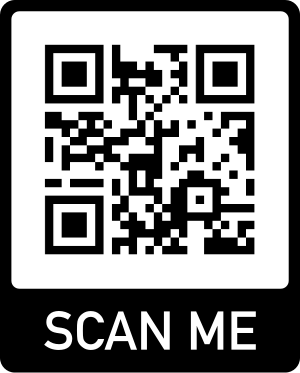

# Link ⇒ `https://tinyurl.com/4j7jsf9t`

# Slides for Transformer ⇒ ` https://tinyurl.com/p8ezwzvm`

# Slides for this Colab ⇒ `https://tinyurl.com/3rde5dnm`

## Introduction

This course is designed for NLP beginners to quickly develop an NLP application from a large language model (LLM). The [Hugging Face Library](https://huggingface.co) is employed to jump-start the importation, development, and deployment of deep learning models based on the Transformer architecture.

### Group Activities

This class will be oriented by group activities. Form a group consisting of at least three members:

- One Python programmer
- One linguist (preferably computer-literate)
- One researcher / business analyst

One member can possess two or more properties and therefore represent two people.

### Course Outline

In the duration of two days, you will learn the following topics:

- **Part I (Theory)**
    1. Architecture of the Transformer model
- **Part II (Easy)**
    1. Hugging Face Library
    2. Zero-shot learning with prompts
    3. Ready-made NLP tasks
    4. Tweaking the pipeline
- **Part III (Intermediate)**
    1. Few-shot learning
    2. Using external datasets
- **Part IV (Advanced)**
    1. Semantic search with FAISS
    2. Retrieval-augmented generation
    3. Model fine-tuning
    4. Tokenizer fine-tuning
    5. Publishing your models and tokenizers to Hugging Face

Have fun!

--------------------

## Part I (Theory)

### Architecture of the Transformer Model

Please click [https://tinyurl.com/p8ezwzvm](https://tinyurl.com/p8ezwzvm) to proceed to the slides.

--------------------

## Part II (Easy)

### Hugging Face Library

The [Hugging Face Library](https://huggingface.co) is a compendium of Transformer-based pretrained models, pretrained text tokenizers, and prepared datasets. It provides an end-to-end pipeline from raw texts to final outputs according to various NLP tasks, facilitating rapid software development. In addition, it also offers a platform where developers can share their models, text tokenizers, and datasets to the HuggingFace community with millions of users worldwide.

#### Installation

The Hugging Face Library can be installed by the following instruction.

In [ ]:
# Zero-shot learning
!pip install -q transformers>=4.41.0    # Transformer model
!pip install -q sentence-transformers   # Text-based transformers

# Few-shot learning
!pip install -q setfit

# Dataset management: loader and splitter
!pip install -q zstandard
!pip install -q datasets

# Vector database
!pip install -q faiss-cpu
!pip install -q faiss-gpu

# Model evaluation
!pip install -q accelerate
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 84.7 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement faiss-gpu (from versions: none)
ERROR: No matching distribution found for faiss-gpu


#### Code Header

Here's the header for our code. We import the following components:

- `pipeline`: end-to-end data pipeline
- `AutoTokenizer`: text tokenizer
- `AutoModel`: interface for LLMs

In [ ]:
from transformers import pipeline
from transformers import AutoTokenizer
from transformers import AutoModel
from datasets import load_dataset, Dataset, DatasetDict

#### Looking for CUDA GPU

In [ ]:
import torch

def get_device():
    # CUDA GPU
    if torch.torch.cuda.is_available():
        return torch.device('cuda:0')
    # Mac GPU
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device('mps')
    # CPU
    else:
        return torch.device('cpu')

#### At First Glance

Once we have installed the Hugging Face, let's give it a go. The code below is a real piece of code for zero-shot text classification.

In [ ]:
# We use a pretrained multilingual DeBERTa with the capability of natural language inference.
model = pipeline(
    task='zero-shot-classification',
    model='MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
    device=get_device()
)

# This is the input text. Note that it can be untokenized!
text = "หมากปริญเผยไม่เคยปิดบังว่ามีแฟนแล้ว"

# This is the label set.
labels = ["politics", "economy", "entertainment", "environment"]

# Classify the text into one of these labels.
output = model(text, labels, multi_label=False)

# Print out the result.
print(f'Input : {text}')
print(f'Output: {output}')
print(f'Most probable class is: {output["labels"][0]} with probability {output["scores"][0]}.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Input : หมากปริญเผยไม่เคยปิดบังว่ามีแฟนแล้ว
Output: {'sequence': 'หมากปริญเผยไม่เคยปิดบังว่ามีแฟนแล้ว', 'labels': ['entertainment', 'politics', 'economy', 'environment'], 'scores': [0.5762775540351868, 0.2532365024089813, 0.11292305588722229, 0.05756291002035141]}
Most probable class is: entertainment with probability 0.5762775540351868.


The predicted class is the label with the highest probability. The labels seen here are sorted according to their probabilities.

<b><u>Note:</u></b> The model `MoritzLaurer/mDeBERTa-v3-base-mnli-xnli` is best for multilingual document classification, because contextual information is learned from the natural language inference task (NLI).

#### Exercise 1 (10 mins)

Let's expand your idea by tweaking the above code, rerunning it, and observing the change of results.

- Change the input text to something else.
- Make incorrect spellings and typos.
- Add/remove labels.
- Make it multi-output classification by setting `multi_label=True`.

Observe the change of results and discuss what's happening.

**<u>ANSWER:</u>** (*Double click here to enter your answer.*)

In [ ]:
# We use a pretrained multilingual DeBERTa with the capability of natural language inference.
model = pipeline(
    task='zero-shot-classification',
    model='MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
    device=get_device()
)

# This is the input text. Note that it can be untokenized!
text = "หมากปริญเผยไม่เคยปิดบังว่ามีแฟนแล้ว"

# This is the label set.
labels = ["politics", "economy", "entertainment", "environment"]

# Classify the text into one of these labels.
output = model(text, labels, multi_label=False)

# Print out the result.
print(f'Input : {text}')
print(f'Output: {output}')
print(f'Most probable class is: {output["labels"][0]} with probability {output["scores"][0]}.')

Device set to use cuda:0


Input : หมากปริญเผยไม่เคยปิดบังว่ามีแฟนแล้ว
Output: {'sequence': 'หมากปริญเผยไม่เคยปิดบังว่ามีแฟนแล้ว', 'labels': ['entertainment', 'politics', 'economy', 'environment'], 'scores': [0.5762775540351868, 0.2532365024089813, 0.11292305588722229, 0.05756291002035141]}
Most probable class is: entertainment with probability 0.5762775540351868.


--------------------

### Zero-Shot Learning with Prompts

<b><u>Zero-shot learning:</u></b> is a machine learning technique that allows a model to classify objects from previously unseen classes, without receiving any specific training for those classes.

*Example:* We train a model to map a given image to a word vector corresponding to its output class. In the dataset, there are only three classes: *dog*, *bird*, and *fish*. However, when we input an image of a cat to the model, it classifies it as *cat* without being trained to recognize it. This is due to the knowledge embedded in the LLM.

In NLP, this task can easily be done by *mask filling*. We input an instruction, or **prompt**, which contains a blank, to the LLM and let it fill it in with its embedded knowledge. In the following piece of code, we give a sentence "`I should write a [MASK] to my boss.`" to the LLM and make it guess the masked word.

In [ ]:
# We use a pretrained DeBERTa with the capability of mask filling.
model = pipeline(
    task='fill-mask',
    model='MilaNLProc/deberta-v3-large-mlm-reddit-gab',
    device=get_device()
)

# The mask is `model.tokenizer.mask_token`.
prompt = 'I should write a ' + model.tokenizer.mask_token + ' to my boss.'

# Now fill in the mask.
output = model(prompt)

# Print out the result.
print(f'Prompt: {prompt}')
for idx, output_entry in enumerate(output):
    print(f'Output {idx}: {output_entry}')

config.json:   0%|          | 0.00/869 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/395 [00:00<?, ?it/s]

DebertaV2ForMaskedLM LOAD REPORT from: MilaNLProc/deberta-v3-large-mlm-reddit-gab
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/400 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Prompt: I should write a [MASK] to my boss.
Output 0: {'score': 0.33844366669654846, 'token': 5142, 'token_str': 'complaint', 'sequence': 'I should write a complaint to my boss.'}
Output 1: {'score': 0.17974847555160522, 'token': 1837, 'token_str': 'letter', 'sequence': 'I should write a letter to my boss.'}
Output 2: {'score': 0.14857171475887299, 'token': 815, 'token_str': 'report', 'sequence': 'I should write a report to my boss.'}
Output 3: {'score': 0.04449044167995453, 'token': 7885, 'token_str': 'petition', 'sequence': 'I should write a petition to my boss.'}
Output 4: {'score': 0.018099790439009666, 'token': 1548, 'token_str': 'statement', 'sequence': 'I should write a statement to my boss.'}


This command `model.tokenizer.mask_token` returns the mask token of the model. We can even print it out if we want to.

In [ ]:
print(model.tokenizer.mask_token)

[MASK]


Note that the mask token varies from models to models and has to be specified with this command. In some LLMs, it's `[MASK]`, while the others may be `<mask>` and `[mask]`. All of them orthographically differ from each other and are treated differently.

<b><u>Prompt-based classification:</u></b> The concept of mask filling can be used in zero-shot text classification. For example, we can use the prompt `"......" The emotion of this text is: [MASK].` to determine the emotion of an input text.

In [ ]:
# We use a pretrained DeBERTa with the capability of mask filling.
model = pipeline(
    task='fill-mask',
    model='MilaNLProc/deberta-v3-large-mlm-reddit-gab',
    device=get_device()
)

# Input text
# text = 'Mary has lost her beloved dog, and her eyes are now tearful.'
text = 'Mary has lost her beloved dog, and her eyes are now tearful.'

# The mask is `model.tokenizer.mask_token`.
# question = 'The emotion of this text is: ' + model.tokenizer.mask_token + ' .'
question = 'The emotion of this text is: ' + model.tokenizer.mask_token + ' .'

# Prompt
prompt = f'"{text}" {question}'
print(f'Prompt: {prompt}')

# The input text and the prompt are put together.
output = model(prompt)

# Print out the result.
for idx, output_entry in enumerate(output):
    print(f'Output {idx} = {output_entry}')

Loading weights:   0%|          | 0/395 [00:00<?, ?it/s]

DebertaV2ForMaskedLM LOAD REPORT from: MilaNLProc/deberta-v3-large-mlm-reddit-gab
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prompt: "Mary has lost her beloved dog, and her eyes are now tearful." The emotion of this text is: [MASK] .
Output 0 = {'score': 0.07433537393808365, 'token': 12819, 'token_str': 'sadness', 'sequence': '"Mary has lost her beloved dog, and her eyes are now tearful." The emotion of this text is: sadness .'}
Output 1 = {'score': 0.07278172671794891, 'token': 26817, 'token_str': 'disgust', 'sequence': '"Mary has lost her beloved dog, and her eyes are now tearful." The emotion of this text is: disgust .'}
Output 2 = {'score': 0.02848113887012005, 'token': 5530, 'token_str': 'tears', 'sequence': '"Mary has lost her beloved dog, and her eyes are now tearful." The emotion of this text is: tears .'}
Output 3 = {'score': 0.017667753621935844, 'token': 17642, 'token_str': 'sorrow', 'sequence': '"Mary has lost her beloved dog, and her eyes are now tearful." The emotion of this text is: sorrow .'}
Output 4 = {'score': 0.014488108456134796, 'token': 10511, 'token_str': 'disappointment', 'sequence':

*Lesson learned:* Multilingual LLMs do not perform well in mask filling, as they tend to fill the mask with words from foreign languages. This is where the monolingual LLMs shine.

#### Exercise 2 (10 mins)

Let's expand our idea by tweaking the above piece of code, rerunning it, and observing the change of results.

- Change the input text for five times.
- Change the prompt for five times.

Observe the change of results and answer the following questions.

1. By changing the input text, how many emotions do you discover?
2. By changing the prompt, how many emotions do you discover?
3. Explain why the change of prompts affects the discovered emotions.

**<u>ANSWER:</u>** (Double click here to enter your answer.)

What we are doing right now is called **prompt engineering**. We seek to find a set of prompts that yield best results according to your objective.

--------------------

### Ready-Made Tasks

The Hugging Face Library provides a pipeline of various NLP tasks. If we don't specify the argument `model` in the command `pipeline`, it will automatically select the best model available for the specified task. However, these best models work well only on English data. For example, we can develop a sentiment analysis in just a few lines.

In [ ]:
# We let the pipeline choose the best model for sentiment analysis.
model = pipeline(
    task='sentiment-analysis',
    device=get_device()
)

# This is the input text.
text = 'I am promoted as the managing director! Let\'s celebrate tonight.'

# Let's run the model.
output = model(text)

# Here's the result.
print(f'Input : {text}')
print(f'Output: {output}')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Input : I am promoted as the managing director! Let's celebrate tonight.
Output: [{'label': 'POSITIVE', 'score': 0.9998561143875122}]


We can discover available tasks by keying in the following command and look for the `task` argument.

In [ ]:
# help(pipeline)

As of May 2023, there are at least 26 ready-made machine learning tasks categorized into four modes as follows. (Much more models can be found [here](https://huggingface.co/models).)

#### NLP

| Tasks | Descriptions | Examples |
|-------|--------------|----------|
| `conversational` | Conversational agent | [PygmalionAI](https://huggingface.co/PygmalionAI/pygmalion-6b) |
| `fill-mask` | Mask filling for zero-shot learning | [BERT](https://huggingface.co/bert-base-uncased) |
| `question-answering` | Question answering (extractive) | [RoBERTa](https://huggingface.co/deepset/roberta-base-squad2) |
| `table-question-answering` | Question answering from a given table | [Tapas](https://huggingface.co/google/tapas-large-finetuned-wtq) |
| `text2text-generation` | Text generation from a given text | [Parrot Paraphraser](https://huggingface.co/prithivida/parrot_paraphraser_on_T5) |
| `text-classification` | Document classification and sentiment analysis | [DistillBERT](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) |
| `sentiment-analysis` | (same as `text-classification`) |
| `text-generation` | Text generation | [GPT-2](https://huggingface.co/gpt2) |
| `token-classification` | Sequence prediction (e.g. word segmentation, POS tagging, and NER) | [BERT](https://huggingface.co/dslim/bert-base-NER) |
| `translation` | Machine translation | [T5](https://huggingface.co/t5-base) |
| `translation_xx_to_yy` | Machine translation from XX to YY (language codes must be small letters) | [T5](https://huggingface.co/t5-base) |
| `summarization` | Automatic text summarization | [BART](https://huggingface.co/facebook/bart-large-cnn) |

#### Speech Processing

| Tasks | Descriptions | Examples |
|-------|--------------|----------|
| `audio-classification` | Audio classification | [XLSR](https://huggingface.co/harshit345/xlsr-wav2vec-speech-emotion-recognition)
| `automatic-speech-recognition` | Automatic speech recognition | [Wav2Vec](https://huggingface.co/jonatasgrosman/wav2vec2-large-xlsr-53-english) |
| `zero-shot-audio-classification` | Zero-shot audio classification | [CLIP-HTSAT](https://huggingface.co/laion/clap-htsat-fused) |

#### Image Processing

| Tasks | Descriptions | Examples |
|-------|--------------|----------|
| `depth-estimation` | Depth estimation | [GLPN](https://huggingface.co/vinvino02/glpn-nyu) |
| `feature-extraction` | Image feature extraction for few-shot learning | [DINO Vision Transformer](https://huggingface.co/facebook/dino-vitb16) |
| `image-classification` | Image classification | [ResNet-50](https://huggingface.co/microsoft/resnet-50) |
| `image-segmentation` | Image segmentation | [ClipSeg](https://huggingface.co/CIDAS/clipseg-rd64-refined) |
| `mask-generation` | Generation of object masks in image processing | [SAM Vision Transformer](https://huggingface.co/facebook/sam-vit-huge) |
| `object-detection` | Object detection | [YOLOS](https://huggingface.co/hustvl/yolos-tiny) |
| `video-classification` | Video classification | [XClip](https://huggingface.co/microsoft/xclip-base-patch32) |
| `zero-shot-classification` | Zero-shot classification | [BART](https://huggingface.co/facebook/bart-large-mnli) |
| `zero-shot-image-classification` | Zero-shot image classification | [CLIP Vision Transformer](https://huggingface.co/openai/clip-vit-large-patch14) |
| `zero-shot-object-detection` | Zero-shot object detection | [OWL Vision Transformer](https://huggingface.co/google/owlvit-base-patch32) |

#### Multimodal Processing

| Tasks | Descriptions | Examples |
|-------|--------------|----------|
| `document-question-answering` | Question answering from scanned documents | [LayoutLM](https://huggingface.co/impira/layoutlm-document-qa) |
| `image-to-text` | Caption generation | [Vision Transformer + GPT2](https://huggingface.co/nlpconnect/vit-gpt2-image-captioning) |
| `visual-question-answering` | Visual question answering | [ViLT](https://huggingface.co/dandelin/vilt-b32-finetuned-vqa) |

#### Exercise 3 (10 mins)

Let's give it a go on the ready-made tasks. Study [RoBERTa-SQUAD2](https://huggingface.co/deepset/roberta-base-squad2) and develop a question answering system that answer the following context and question.

**Context:**
> Bangkok, officially known in Thai as Krung Thep Maha Nakhon and colloquially as Krung Thep, is the capital and most populous city of Thailand. The city occupies 1,568.7 square kilometres (605.7 sq mi) in the Chao Phraya River delta in central Thailand and has an estimated population of 10.539 million as of 2020, 15.3 percent of the country's population. Over 14 million people (22.2 percent) lived within the surrounding Bangkok Metropolitan Region at the 2010 census, making Bangkok an extreme primate city, dwarfing Thailand's other urban centres in both size and importance to the national economy.
>
> Bangkok traces its roots to a small trading post during the Ayutthaya Kingdom in the 15th century, which eventually grew and became the site of two capital cities, Thonburi in 1768 and Rattanakosin in 1782. Bangkok was at the heart of the modernization of Siam, later renamed Thailand, during the late-19th century, as the country faced pressures from the West. The city was at the centre of Thailand's political struggles throughout the 20th century, as the country abolished absolute monarchy, adopted constitutional rule, and underwent numerous coups and several uprisings. The city, incorporated as a special administrative area under the Bangkok Metropolitan Administration in 1972, grew rapidly during the 1960s through the 1980s and now exerts a significant impact on Thailand's politics, economy, education, media and modern society.
>
> The Asian investment boom in the 1980s and 1990s led many multinational corporations to locate their regional headquarters in Bangkok. The city is now a regional force in finance, business and pop culture. It is an international hub for transport and health care, and has emerged as a centre for the arts, fashion, and entertainment. The city is known for its street life and cultural landmarks, as well as its red-light districts. The Grand Palace and Buddhist temples including Wat Arun and Wat Pho stand in contrast with other tourist attractions such as the nightlife scenes of Khaosan Road and Patpong. Bangkok is among the world's top tourist destinations, and has been named the world's most visited city consistently in several international rankings.
>
> Bangkok's rapid growth coupled with little urban planning has resulted in a haphazard cityscape and inadequate infrastructure. Despite an extensive expressway network, an inadequate road network and substantial private car usage have led to chronic and crippling traffic congestion, which caused severe air pollution in the 1990s. The city has since turned to public transport in an attempt to solve the problem, operating eight urban rail lines and building other public transit, but congestion still remains a prevalent issue.

**Question:**
> What is the nearest river to Bangkok?

In [ ]:
## ENTER YOUR CODE HERE

# After running pip install haystack-ai "transformers[torch,sentencepiece]"

!pip install haystack-ai "transformers[torch,sentencepiece]"

from haystack import Document
from haystack.components.readers import ExtractiveReader

docs = [
    Document(content="Python is a popular programming language"),
    Document(content="python ist eine beliebte Programmiersprache"),
]

reader = ExtractiveReader(model="deepset/roberta-base-squad2")
reader.warm_up()

question = "What is a popular programming language?"
result = reader.run(query=question, documents=docs)
# {'answers': [ExtractedAnswer(query='What is a popular programming language?', score=0.5740374326705933, data='python', document=Document(id=..., content: '...'), context=None, document_offset=ExtractedAnswer.Span(start=0, end=6),...)]}


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 592.1/592.1 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.3/137.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 5.0 MB/s eta 0:00:00


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

##### Solution

In [ ]:
qa = pipeline('question-answering', device=get_device())

question = 'What is the nearest river to Bangkok?'

context = '''
    Bangkok, officially known in Thai as Krung Thep Maha Nakhon and colloquially as Krung Thep, is the capital and most populous city of Thailand. The city occupies 1,568.7 square kilometres (605.7 sq mi) in the Chao Phraya River delta in central Thailand and has an estimated population of 10.539 million as of 2020, 15.3 percent of the country's population. Over 14 million people (22.2 percent) lived within the surrounding Bangkok Metropolitan Region at the 2010 census, making Bangkok an extreme primate city, dwarfing Thailand's other urban centres in both size and importance to the national economy.

    Bangkok traces its roots to a small trading post during the Ayutthaya Kingdom in the 15th century, which eventually grew and became the site of two capital cities, Thonburi in 1768 and Rattanakosin in 1782. Bangkok was at the heart of the modernization of Siam, later renamed Thailand, during the late-19th century, as the country faced pressures from the West. The city was at the centre of Thailand's political struggles throughout the 20th century, as the country abolished absolute monarchy, adopted constitutional rule, and underwent numerous coups and several uprisings. The city, incorporated as a special administrative area under the Bangkok Metropolitan Administration in 1972, grew rapidly during the 1960s through the 1980s and now exerts a significant impact on Thailand's politics, economy, education, media and modern society.

    The Asian investment boom in the 1980s and 1990s led many multinational corporations to locate their regional headquarters in Bangkok. The city is now a regional force in finance, business and pop culture. It is an international hub for transport and health care, and has emerged as a centre for the arts, fashion, and entertainment. The city is known for its street life and cultural landmarks, as well as its red-light districts. The Grand Palace and Buddhist temples including Wat Arun and Wat Pho stand in contrast with other tourist attractions such as the nightlife scenes of Khaosan Road and Patpong. Bangkok is among the world's top tourist destinations, and has been named the world's most visited city consistently in several international rankings.

    Bangkok's rapid growth coupled with little urban planning has resulted in a haphazard cityscape and inadequate infrastructure. Despite an extensive expressway network, an inadequate road network and substantial private car usage have led to chronic and crippling traffic congestion, which caused severe air pollution in the 1990s. The city has since turned to public transport in an attempt to solve the problem, operating eight urban rail lines and building other public transit, but congestion still remains a prevalent issue.
'''

qa_input = {
    'question': question,
    'context': context
}
output = qa(qa_input)
# Alternative usage: output = qa(question=question, context=context)

print(f'Question: {qa_input["question"]}')
print(f'Context : {qa_input["context"]}')
print(f'Output  : {output}')

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


Question: What is the nearest river to Bangkok?
Context : 
    Bangkok, officially known in Thai as Krung Thep Maha Nakhon and colloquially as Krung Thep, is the capital and most populous city of Thailand. The city occupies 1,568.7 square kilometres (605.7 sq mi) in the Chao Phraya River delta in central Thailand and has an estimated population of 10.539 million as of 2020, 15.3 percent of the country's population. Over 14 million people (22.2 percent) lived within the surrounding Bangkok Metropolitan Region at the 2010 census, making Bangkok an extreme primate city, dwarfing Thailand's other urban centres in both size and importance to the national economy.

    Bangkok traces its roots to a small trading post during the Ayutthaya Kingdom in the 15th century, which eventually grew and became the site of two capital cities, Thonburi in 1768 and Rattanakosin in 1782. Bangkok was at the heart of the modernization of Siam, later renamed Thailand, during the late-19th century, as the count

--------------------

### Tweaking the Pipeline

Let's take a look at the following code for sentiment analysis.

In [ ]:
model = pipeline('sentiment-analysis', device=get_device())

texts = [
    'I\'m promoted as the managing director! Let\'s celebrate tonight.',
    'Unfortunately, I\'ll be having a meeting tonight. I can\'t join the party.'
]

outputs = model(texts)

for i in range(len(texts)):
    print(f'Input : {texts[i]}')
    print(f'Output: {outputs[i]}')
    print()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


Input : I'm promoted as the managing director! Let's celebrate tonight.
Output: {'label': 'POSITIVE', 'score': 0.9998575448989868}

Input : Unfortunately, I'll be having a meeting tonight. I can't join the party.
Output: {'label': 'NEGATIVE', 'score': 0.9996528625488281}



Behind the scene, there are three steps in the pipeline.

- **Step 1 (Tokenization):** Each input text is tokenized with a model-specific tokenizer. It results in a token matrix, whose each row represents a vector of token IDs. Note that tokens are <u>*NOT*</u> equivalent to words and the results may vary from tokenizers to tokenizers.
- **Step 2 (Model):** The token matrix is fed to the model, and output vectors are produced according to the task. The output is usually in the form of *logit* vector. Note that the used tokenizer must be compatible with the model.
- **Step 3 (Post-Processing):** The *logit* output vector is finally converted to the prediction result.

Breaking the pipeline down into steps allows us to customize our model more flexibly. This is a much preferred way of model implementation in practice.

#### Step 1: Tokenization

**Tokenization:** is the process of breaking a text into subwords by means of statistics. All input texts must be tokenized before feeding them to the model. There are three tokenization algorithms for LLMs:

- `BPE` (Byte-Pair Encoding): A collocation of characters is combined into a unit if its frequency exceeds the threshold.
- `WordPiece`: A collocation of characters is combined into a unit if its frequency exceeds threshold and is in the top-$n$ list.
- `SentencePiece`: A collocation of characters is combined into a unit if its unigram probability maximizes the probability of the entire input text.

The state-of-the-art technique for tokenization is `SentencePiece` and will be used in this tutorial.

Suppose we have the following texts.

In [ ]:
texts = [
    'I\'m promoted as the managing director! Let\'s celebrate tonight.',
    'Unfortunately, I\'ll be having a meeting tonight. I can\'t join the party.',
    'I\'m looking forward to having lunch with you though.'
]

We can tokenize these texts with a pretrained tokenizer. A pretrained tokenizer can be downloaded by the command `AutoTokenizer.from_pretrained`.

In [ ]:
from transformers import AutoTokenizer

# Checkpoint of tokenizer
cpt_tokenizer = 'distilbert-base-uncased-finetuned-sst-2-english'
tokenizer = AutoTokenizer.from_pretrained(cpt_tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

We feed the texts to the pretrained tokenizer and obtain the output as follows. The arguments for tokenization are:

- `padding`: Fill up short texts to the maximum acceptable length.
- `truncation`: Truncate long texts to the maximum acceptable length.
- `return_tensors`: Return the results in the specified format (`pt` for PyTorch, `np` for Numpy, and `tf` for TensorFlow).

In [ ]:
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
inputs.to(get_device())      # Load the matrix to GPU
print(inputs)

{'input_ids': tensor([[ 101, 1045, 1005, 1049, 3755, 2004, 1996, 6605, 2472,  999, 2292, 1005,
         1055, 8439, 3892, 1012,  102,    0,    0,    0,    0],
        [ 101, 6854, 1010, 1045, 1005, 2222, 2022, 2383, 1037, 3116, 3892, 1012,
         1045, 2064, 1005, 1056, 3693, 1996, 2283, 1012,  102],
        [ 101, 1045, 1005, 1049, 2559, 2830, 2000, 2383, 6265, 2007, 2017, 2295,
         1012,  102,    0,    0,    0,    0,    0,    0,    0]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]],
       device='cuda:0')}


The output of tokenization is a dictionary with two keys: `input_ids` and `attention_mask`.
- Each row of the `input_ids` tensor is a sequence of token IDs, and ID `0` represents an empty subword.
- Each row of the `attention_mask` tensor is a sequence of subword masks, and `1` means the corresponding subword is taken into account.

If we wish to interpret the ID sequence, we can use the command `tokenizer.decode` as follows.

In [ ]:
tokenizer.decode(inputs['input_ids'][0])

"[CLS] i'm promoted as the managing director! let's celebrate tonight. [SEP] [PAD] [PAD] [PAD] [PAD]"

Or if we prefer the tokenized subwords, we can use the command `tokenizer.convert_ids_to_tokens` instead.

In [ ]:
tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

['[CLS]',
 'i',
 "'",
 'm',
 'promoted',
 'as',
 'the',
 'managing',
 'director',
 '!',
 'let',
 "'",
 's',
 'celebrate',
 'tonight',
 '.',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

#### Step 2: Model

Once we have tokenized the input texts and obtained the input dictionary, we are now ready to perform prediction.

##### Classification

We can perform sequence classification with a pretrained model with the command `AutoModelForSequenceClassification.from_pretrained`.

In [ ]:
from transformers import AutoModelForSequenceClassification

# Checkpoint for the pretrained model
cpt_model = 'distilbert-base-uncased-finetuned-sst-2-english'
classifier = AutoModelForSequenceClassification.from_pretrained(cpt_model)
classifier.to(get_device())

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


We can straightforwardly feed the output of tokenization to the model. The output will be in the format of *logit* vectors, where each row represents the prediction scores for each class.

In [ ]:
# Perform prediction
outputs = classifier(**inputs)

print(f'Input :\n{inputs}')
print(f'Output:\n{outputs}')

Input :
{'input_ids': tensor([[ 101, 1045, 1005, 1049, 3755, 2004, 1996, 6605, 2472,  999, 2292, 1005,
         1055, 8439, 3892, 1012,  102,    0,    0,    0,    0],
        [ 101, 6854, 1010, 1045, 1005, 2222, 2022, 2383, 1037, 3116, 3892, 1012,
         1045, 2064, 1005, 1056, 3693, 1996, 2283, 1012,  102],
        [ 101, 1045, 1005, 1049, 2559, 2830, 2000, 2383, 6265, 2007, 2017, 2295,
         1012,  102,    0,    0,    0,    0,    0,    0,    0]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]],
       device='cuda:0')}
Output:
SequenceClassifierOutput(loss=None, logits=tensor([[-4.2510,  4.6053],
        [ 4.3781, -3.5874],
        [-3.9238,  4.2087]], device='cuda:0', grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


We usually have to deal with the logits part of the results only.

In [ ]:
# The output vector for each text in terms of logits
logits = outputs.logits

print(f'Logits:\n{logits}')
print(f'Shape : {logits.shape}')

Logits:
tensor([[-4.2510,  4.6053],
        [ 4.3781, -3.5874],
        [-3.9238,  4.2087]], device='cuda:0', grad_fn=<AddmmBackward0>)
Shape : torch.Size([3, 2])


If we wish to know the mapping from class IDs to labels, we can refer to the command `config.id2label`.

In [ ]:
print(classifier.config.id2label)

{0: 'NEGATIVE', 1: 'POSITIVE'}


##### Text Encoding to Vector

We can encode an input text as a vector with a pretrained model. To do so, we load the pretrained model with the command `AutoModel.from_pretrained`.

In [ ]:
from transformers import AutoModel

# Checkpoint of model
cpt_model = 'distilbert-base-uncased-finetuned-sst-2-english'
encoder = AutoModel.from_pretrained(cpt_model)
encoder.to(get_device())

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

We can then feed the output of tokenization to the model straight away.

In [ ]:
outputs = encoder(**inputs)
# print(outputs)
print(outputs.last_hidden_state.shape)

torch.Size([3, 21, 768])


The output of text encoding is a tensor, where:
- Dimension 0 is the number of input texts.
- Dimension 1 is the maximum number of subwords.
- Dimension 2 is the dimension of embedding vectors.

#### AutoModels

We can do a lot more with the pretrained model. Simply replace `AutoModelForClassification` with one of these classes. You'll find that these tasks are already listed in the ready-made list.

In [ ]:
import transformers
for x in dir(transformers):
    if x.startswith('AutoModelFor'):
        print(x)

AutoModelForAudioClassification
AutoModelForAudioFrameClassification
AutoModelForAudioTokenization
AutoModelForAudioXVector
AutoModelForCTC
AutoModelForCausalLM
AutoModelForDepthEstimation
AutoModelForDocumentQuestionAnswering
AutoModelForImageClassification
AutoModelForImageSegmentation
AutoModelForImageTextToText
AutoModelForImageToImage
AutoModelForInstanceSegmentation
AutoModelForKeypointDetection
AutoModelForKeypointMatching
AutoModelForMaskGeneration
AutoModelForMaskedImageModeling
AutoModelForMaskedLM
AutoModelForMultimodalLM
AutoModelForMultipleChoice
AutoModelForNextSentencePrediction
AutoModelForObjectDetection
AutoModelForPreTraining
AutoModelForQuestionAnswering
AutoModelForSemanticSegmentation
AutoModelForSeq2SeqLM
AutoModelForSequenceClassification
AutoModelForSpeechSeq2Seq
AutoModelForTableQuestionAnswering
AutoModelForTextEncoding
AutoModelForTextToSpectrogram
AutoModelForTextToWaveform
AutoModelForTimeSeriesPrediction
AutoModelForTokenClassification
AutoModelForUnivers

If you are wondering how to use a particular `AutoModel`, you can ask for help for its `forward` method. The help message usually provides a recipe for using the model. For example,

In [ ]:
from transformers import AutoModelForQuestionAnswering

cpt_model = 'distilbert-base-uncased-finetuned-sst-2-english'
model = AutoModelForQuestionAnswering.from_pretrained(cpt_model)
help(model.forward)

Some weights of DistilBertForQuestionAnswering were not initialized from the model checkpoint at distilbert-base-uncased-finetuned-sst-2-english and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Help on method forward in module transformers.models.distilbert.modeling_distilbert:

forward(input_ids: Optional[torch.Tensor] = None, attention_mask: Optional[torch.Tensor] = None, head_mask: Optional[torch.Tensor] = None, inputs_embeds: Optional[torch.Tensor] = None, start_positions: Optional[torch.Tensor] = None, end_positions: Optional[torch.Tensor] = None, output_attentions: Optional[bool] = None, output_hidden_states: Optional[bool] = None, return_dict: Optional[bool] = None) -> Union[transformers.modeling_outputs.QuestionAnsweringModelOutput, tuple[torch.Tensor, ...]] method of transformers.models.distilbert.modeling_distilbert.DistilBertForQuestionAnswering instance
    The [`DistilBertForQuestionAnswering`] forward method, overrides the `__call__` special method.

    <Tip>

    Although the recipe for forward pass needs to be defined within this function, one should call the [`Module`]
    instance afterwards instead of this since the former takes care of running the pre and

It is highly recommended to use the pretrained tokenizer provided with a pretrained model of your choice, as it usually yields the best accuracy.

#### Exercise 4 (15 mins)

We wish to develop a masked language model from the [DeBERTa](https://huggingface.co/MilaNLProc/deberta-v3-large-mlm-reddit-gab) without using the `pipeline`. I have already broken down the method into several steps as follows.

**Step 1:** Read the help message of `AutoModelForMaskedLM` of the DistilBERT. Run this code to do so. Study the recipe very well.

Note that I've already loaded the tokenizer and model for you.

In [ ]:
from transformers import AutoModelForMaskedLM

cpt_model = 'MilaNLProc/deberta-v3-large-mlm-reddit-gab'
tokenizer = AutoTokenizer.from_pretrained(cpt_model)
model = AutoModelForMaskedLM.from_pretrained(cpt_model)
help(model.forward)

Help on method forward in module transformers.models.deberta_v2.modeling_deberta_v2:

forward(input_ids: Optional[torch.Tensor] = None, attention_mask: Optional[torch.Tensor] = None, token_type_ids: Optional[torch.Tensor] = None, position_ids: Optional[torch.Tensor] = None, inputs_embeds: Optional[torch.Tensor] = None, labels: Optional[torch.Tensor] = None, output_attentions: Optional[bool] = None, output_hidden_states: Optional[bool] = None, return_dict: Optional[bool] = None) -> Union[tuple, transformers.modeling_outputs.MaskedLMOutput] method of transformers.models.deberta_v2.modeling_deberta_v2.DebertaV2ForMaskedLM instance
    The [`DebertaV2ForMaskedLM`] forward method, overrides the `__call__` special method.

    <Tip>

    Although the recipe for forward pass needs to be defined within this function, one should call the [`Module`]
    instance afterwards instead of this since the former takes care of running the pre and post processing steps while
    the latter silently ignor

**Step 2:** Show the mask token and its ID of this pretrained tokenizer.

In [ ]:
## ENTER YOUR CODE HERE

**Step 3:** Load a classifier from the DistilBERT.

In [ ]:
## ENTER YOUR CODE HERE

**Step 4:** Predict the missing word in the sentence `The capital of France is [MASK]`. Retrieve only the logits part of the result.

In [ ]:
## ENTER YOUR CODE HERE

**Step 5:** Find the predicted subword by running the following code.

In [ ]:
# mask_token_index = (input_ids.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
# print(f'mask_token_index: {mask_token_index}')

# predicted_token_id = logits[0, mask_token_index].argmax(axis=-1)
# print(f'predicted_token_id: {predicted_token_id}')

# predicted_word = tokenizer.decode(predicted_token_id)
# print(f'predicted_subword: {predicted_word}')

##### Solution

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForMaskedLM

# Step 1
cpt_model = 'MilaNLProc/deberta-v3-large-mlm-reddit-gab'
tokenizer = AutoTokenizer.from_pretrained(cpt_model)
model = AutoModelForMaskedLM.from_pretrained(cpt_model)
model.to(get_device())

# Step 2
print(f'mask_token    : {tokenizer.mask_token}')
print(f'mask_token_id : {tokenizer.mask_token_id}')
print()

# Step 3
text = 'The capital of France is ' + tokenizer.mask_token + '.'
input_ids = tokenizer(text, return_tensors='pt')
input_ids.to(get_device())
print(f'input_ids:\n{input_ids}')
print()

# Step 4
outputs = model(**input_ids)
logits = outputs.logits
print(f'logits:\n{logits}')
print()

# Step 5
mask_token_index = (input_ids.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
print(f'mask_token_index: {mask_token_index}')

predicted_token_id = logits[0, mask_token_index].argmax(axis=-1)
print(f'predicted_token_id: {predicted_token_id}')

predicted_word = tokenizer.decode(predicted_token_id)
print(f'predicted_subword: {predicted_word}')

mask_token    : [MASK]
mask_token_id : 128000

input_ids:
{'input_ids': tensor([[     1,    279,   1909,    265,   2378,    269, 128000,    323,      2]],
       device='cuda:0'), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}

logits:
tensor([[[-3.6524,  3.2113,  4.4275,  ..., -3.3531, -0.1113,  4.4327],
         [-5.0733,  3.4625,  5.6263,  ..., -5.0933, -0.4031, -0.0586],
         [-4.7530,  5.1320,  3.8703,  ..., -4.2600, -2.5449, -0.5685],
         ...,
         [-3.0094,  2.0060,  4.8134,  ..., -2.3597,  2.2458,  2.2542],
         [-2.9071,  5.2287,  4.8389,  ..., -2.9049, -0.9334,  4.8716],
         [-4.5489,  3.2513,  4.1827,  ..., -4.3043,  0.0727,  4.8984]]],
       device='cuda:0', grad_fn=<ViewBackward0>)

mask_token_index: tensor([6], device='cuda:0')
predicted_token_id: tensor([3045], device='cuda:0')
predicted_subword: Paris


--------------------

## Part III (Intermediate)

### Few-Shot Learning

**Few-shot learning:** is a machine learning method that allows a model to learn how to classify objects from previously unseen classes, based on a small example set. This is sometimes called **in-context learning**, because we have to provide the context to narrow down the learning scope.

*Example:* We can train the model to classify an email to four categories: `work`, `study`, `leisure`, and `spam`, by providing several email samples for each class. The model will use the knowledge embedded in the LLM to complete the task on its own.

To perform few-shot learning, we do not actually train the classification model. Instead, we train a **similarity model** $\mathrm{sim}(\mathbf{x}, \mathbf{x}')$, where $\mathbf{x}$ and $\mathbf{x}'$ are two examples.

- If $\mathbf{x}$ and $\mathbf{x}'$ belong to the same groups, $\mathrm{sim}(\mathbf{x}, \mathbf{x}')$ should be $1$.
- If $\mathbf{x}$ and $\mathbf{x}'$ belong to different groups, $\mathrm{sim}(\mathbf{x}, \mathbf{x}')$ should be $0$.

The training with backpropagation is done based on the above constraints until convergence. Contrastive learning is employed for training the similarity model, where we use more negative samples with $\mathbf{sim}(\mathbf{x}, \mathbf{x}') = 0$ than positive samples with $\mathbf{sim}(\mathbf{x}, \mathbf{x}') = 1$.

Because we train the similarity model, the dataset for training is alternatively called **support set**. There are also some jargons we have to know:

- $k$-way means there are $k$ classes.
- $n$-shot means each class has $n$ examples.

We can therefore refer to a support set as $k$-way and $n$-shot.

In other words, few-shot learning is a kind of *meta learning*, where the machine learns how to learn. In this case, few-shot learning learns how to measure the similarity between two examples, enabling the classification task.

Luckily, we don't have to start from scratch when jumping into few-shot learning. The library `setfit` implements the few-shot learning framework with customizable options.

#### SetFit Library

Here's how we install the `setfit` library.

In [ ]:
!pip install -q setfit

#### Headers

Once we've installed it, we can use it by specifying the following headers.

In [ ]:
from setfit import SetFitModel, SetFitTrainer
from sentence_transformers.losses import CosineSimilarityLoss

ImportError: cannot import name 'default_logdir' from 'transformers.training_args' (/usr/local/lib/python3.12/dist-packages/transformers/training_args.py)

To make the SetFit library runnable, we have to turn off WanDB for now.

In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'

Moreover, these headers also help facilitate our job in few-shot learning.

In [ ]:
# For loading an online dataset from Hugging Face
from datasets import load_dataset, DatasetDict

# For splitting the dataset into the train-test sets
from sklearn.model_selection import train_test_split

#### Few-Shot Learning for Social Media Abuse

Let's develop a simple detection model for social media abuse using few-shot learning.

##### Dataset Loading

First, we use the [socialmedia-abuse dataset](https://huggingface.co/datasets/StatsGary/socialmedia-abuse) provided on the Hugging Face. We can download it with the command `load_dataset`.

In [ ]:
# dataset = load_dataset('StatsGary/socialmedia-abuse')
dataset = load_dataset('tweet_eval', 'stance_atheism')
# dataset = load_dataset('tweet_eval', 'stance_climate')

README.md: 0.00B [00:00, ?B/s]

stance_atheism/train-00000-of-00001.parq(…):   0%|          | 0.00/36.5k [00:00<?, ?B/s]

stance_atheism/test-00000-of-00001.parqu(…):   0%|          | 0.00/19.4k [00:00<?, ?B/s]

stance_atheism/validation-00000-of-00001(…):   0%|          | 0.00/6.44k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/461 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/220 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/52 [00:00<?, ? examples/s]

We can take a sneak peek of the dataset with the command `to_pandas`.

In [ ]:
dataset['train'].to_pandas()

,text,label
0,"@user Bless Almighty God, Almighty Holy Spirit...",1
1,"Take away hatred from some people, and you hav...",1
2,I took my troubles to the Lord: I cried out to...,1
3,You can't think by yourself about life and bel...,2
4,RT @user Humanist love to everyone at #100AEUA...,0
...,...,...
456,Pain and setbacks are a part of life. Stay in ...,1
457,"Light is not called into Light, its called int...",1
458,Now that the SCOC has ruled Canadians have fre...,2
459,Indigenous would lose more than Madhesi if da ...,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##### Setting up the Trainer

Once we've got the dataset right, we now setup the trainer.

The documentation of SetFit says we need around 2,000 samples for each class to make efficient prediction. So we simply up-sample the training data by eight folds.

In [ ]:
# num_class = 2
num_class = 3
train_ds = dataset['train'].shuffle().select(range(8 * num_class))
eval_ds = dataset['validation']

We then use the pretrained sentence transformer [mpnet](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) to encode all texts in the training set. Note that the number of classes is specified by the argument `num_labels`. This number varies from datasets to datasets.

In [ ]:
# model = SetFitModel.from_pretrained('all-mpnet-base-v2', num_labels=2)
# model = SetFitModel.from_pretrained('all-mpnet-base-v2', num_labels=3)
model = SetFitModel.from_pretrained('all-mpnet-base-v2')
model.to(get_device())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Next, we setup the trainer as follows.

In [ ]:
trainer = SetFitTrainer(
    model=model,                       # Sentence transformer
    train_dataset=train_ds,            # Training set
    eval_dataset=eval_ds,              # Test set
    loss_class=CosineSimilarityLoss,   # Similarity measure
    batch_size=16,
    num_iterations=20,                 # Negative samples for contrastive learning
    column_mapping={"text": "text", "label": "label"},
    num_epochs=2,
    # report_to='none'
)

/tmp/ipython-input-3795334520.py:1: DeprecationWarning: `SetFitTrainer` has been deprecated and will be removed in v2.0.0 of SetFit. Please use `Trainer` instead.
  trainer = SetFitTrainer(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinf

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

##### Running the Trainer

Then, we run the trainer accordingly. This step takes 11 minutes on CPU-only training. Let's take a break while the trainer is running.

In [ ]:
trainer.train()     # This step takes 11 minutes on CPU-only training.

***** Running training *****
  Num unique pairs = 960
  Batch size = 16
  Num epochs = 2


Step,Training Loss
1,0.264700
50,0.080500
100,0.002400


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


```
Applying column mapping to training dataset
Generating Training Pairs: 100%
20/20 [00:00<00:00, 271.30it/s]
***** Running training *****
  Num examples = 640
  Num epochs = 2
  Total optimization steps = 80
  Total train batch size = 16
Epoch: 100%         2/2 [10:36<00:00, 314.05s/it]
Iteration: 100%     40/40 [05:42<00:00, 7.87s/it]
Iteration: 100%     40/40 [04:54<00:00, 7.58s/it]
```

##### Using the Resultant Model

We can make prediction on unseen texts with the command `model.predict`.

In [ ]:
texts = [
    'I\'m not sure if there is the Creator.',
    'Please stay close to Jesus. He\'s the savior.',
    'Mary stays tolerant in the multi-cultural community.'
]

model.predict(texts)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


tensor([1, 1, 1])

```
tensor([1, 0, 1])
```

##### Evaluation

Finally, we assess the resultant model on our test set.

In [ ]:
metrics = trainer.evaluate()
print(metrics)

***** Running evaluation *****
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'accuracy': 0.6730769230769231}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


```
Applying column mapping to evaluation dataset
***** Running evaluation *****
Downloading builder script: 100%     4.20k/4.20k [00:00<00:00, 171kB/s]
{'accuracy': 1.0}
```

##### Saving the Model

We can save the model with the command `model.save_pretrained`.

In [ ]:
model.save_pretrained('./my_model.cpt')

#### Exercise 5 (30 mins)

Let's develop a stance detection model for climate change. Study the [tweet_eval](https://huggingface.co/datasets/tweet_eval) dataset, and change the subset to `stance_climate`. The training set is in the category `train`, while the test set is in the category `test`.

Develop a few-shot learning model that predicts a stance regarding climate change for each tweet.

In [ ]:
## ENTER YOUR CODE HERE

##### Solution

<font color=red>**CAUTION:**</font> It takes a very long running time in the CPU-only mode.

In [ ]:
dataset = load_dataset('tweet_eval', 'stance_climate')
print(dataset)

# model = SetFitModel.from_pretrained('all-mpnet-base-v2', num_labels=3)
model = SetFitModel.from_pretrained('all-mpnet-base-v2')

trainer = SetFitTrainer(
    model=model,                       # Sentence transformer
    train_dataset=dataset['train'],    # Training set
    eval_dataset=dataset['test'],      # Test set
    loss_class=CosineSimilarityLoss,   # Similarity measure
    batch_size=16,
    num_iterations=20,                 # Negative samples for contrastive learning
    column_mapping={"text": "text", "label": "label"},
    num_epochs=2,
    learning_rate=2e-5
)

trainer.train()

metrics = trainer.evaluate()
print(metrics)

stance_climate/train-00000-of-00001.parq(…):   0%|          | 0.00/28.1k [00:00<?, ?B/s]

stance_climate/test-00000-of-00001.parqu(…):   0%|          | 0.00/14.9k [00:00<?, ?B/s]

stance_climate/validation-00000-of-00001(…):   0%|          | 0.00/5.47k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/355 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/169 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/40 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 355
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 169
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 40
    })
})


KeyboardInterrupt: 

--------------------

### Using External Datasets

Apart from online datasets, we can also use local and remote datasets in training. This can be done by using the command `load_dataset`.

In [ ]:
# For loading an online dataset from Hugging Face
from datasets import load_dataset, DatasetDict

#### Local Dataset

For example, let's download the [SQuAD Dataset](https://github.com/crux82/squad-it/) into the local disk. We further assume that the dataset is in the JSON format.

In [ ]:
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-train.json.gz
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-test.json.gz

!gunzip SQuAD_it-*.json.gz

There are two files to load: one as the training set and the other as the test set.

In [ ]:
!ls SQuAD_it*

Let's take a sneak peek of the dataset. It's a simple JSON file. Each entry consists of the file `data`.

In [ ]:
!head -n 20 SQuAD_it-train.json

We can load the files into specific splits (e.g. `train` and `test`) by specifying them in a dictionary. Then we use the command `load_dataset`.

In [ ]:
data_files = {
    'train': 'SQuAD_it-train.json',
    'test': 'SQuAD_it-test.json'
}
dataset = load_dataset('json', data_files=data_files, field='data')

This is the data statistics.

In [ ]:
print(dataset)

If you wish to see what's in the dataset, you can uncomment and run the following code.

In [ ]:
# dataset['train'][0]

#### Remote Dataset

If your dataset is remote, simply specify its URL. The command `load_dataset` will take care of it automatically.

In [ ]:
url = "https://github.com/crux82/squad-it/raw/master/"
data_files = {
    "train": url + "SQuAD_it-train.json.gz",
    "test": url + "SQuAD_it-test.json.gz",
}
dataset = load_dataset('json', data_files=data_files, field='data')

In [ ]:
print(dataset)

#### Streaming Big Dataset

In the case where a dataset becomes very large, we cannot load it onto the memory in one go as it will fill up the memory quite quickly. To save up the memory usage, we can opt for dataset streaming instead.

For example, [PubMed](https://pubmed.ncbi.nlm.nih.gov/) is the largest corpus of 15,518,009 medical documents. It takes about 20GB of RAM when loading it into the memory.

This is how we load PubMed as a data stream. Note that the argument `streaming` is set to `True`.

In [ ]:
# data_files = 'https://the-eye.eu/public/AI/pile_preliminary_components/PUBMED_title_abstracts_2019_baseline.jsonl.zst'

# dataset_stream = load_dataset(
#     'json', data_files=data_files, split='train', streaming=True
# )

dataset_stream = load_dataset('pubmed', streaming=True)

print(dataset_stream)

It is recommended that the dataset stream should be processed in batches. For example, we can tokenize each batch and stream it to the next process.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

dataset_stream_tokenized = dataset_stream.map(
    lambda item: tokenizer(item['text']),
    batched=True, batch_size=5
)

The code below shows an example of processing each data batch. We simply print their `text` fields out.

In [ ]:
cnt = 0
for batch in dataset_stream_tokenized:
    print(batch['text'])
    if cnt < 2: cnt += 1
    else: break

#### Publishing Your Datasets

Consult the method for uploading your dataset to Hugging Face by following this [link](https://huggingface.co/docs/datasets/upload_dataset).

--------------------

## Part IV (Advanced)

### Semantic Search with FAISS

FAISS (Facebook AI Semantic Search) is a library that facilitates information retrieval with semantic vectors. Once texts are converted into vectors, we can search through them with a vectorized query.

#### Indexing a Dataset

First, we have to construct a vector database. We choose the test set of the [tweet_eval/irony](https://huggingface.co/datasets/tweet_eval) as a testbed.

In [ ]:
dataset = load_dataset('tweet_eval', 'irony')
print(dataset)

Next, we load a pretrained tokenizer.

In [ ]:
cpt_model = 'sentence-transformers/multi-qa-mpnet-base-dot-v1'

tokenizer = AutoTokenizer.from_pretrained(cpt_model)
model = AutoModel.from_pretrained(cpt_model)
model.to(get_device())

To use FAISS, we have to identify how we select the vector representation of a text. In most cases, we choose the vector of the first token `[CLS]` as the representation. This technique is called **CLS pooling**.

In [ ]:
def cls_pooling(model_output):
    return model_output.last_hidden_state[:, 0]

This function computes a vector representation of each text in the given list. Each text is tokenized into subwords, encoded with the model, and finally CLS-pooled.

In [ ]:
def get_embeddings(text_list):
    # Tokenize each text in the list.
    encoded_input = tokenizer(
        text_list, padding=True, truncation=True, return_tensors='pt'
    )

    # Encode each text into a vector representation
    # and keep the structure of the input dictionary.
    encoded_input = {k: v.to(get_device()) for k, v in encoded_input.items()}

    # Apply the input dictionary to the model.
    model_output = model(**encoded_input)

    # Perform CLS pooling.
    return cls_pooling(model_output)

Next, we can add vector representations as a new column to the dataset. Note that we have to convert the output vector representations into the Numpy format. This can be done by using the command `detach` (get rid of PyTorch's gradients), `cpu` (relocate to the main memory), and `numpy` (convert it to Numpy matrix).

In [ ]:
embeddings_dataset = dataset['test'].map(
    lambda item: {
        'embeddings': get_embeddings(item['text']).detach().cpu().numpy()[0]
    }
)

We can see a new column `embeddings`.

In [ ]:
print(embeddings_dataset)

Finally, use the vector representation as the FAISS index.

In [ ]:
embeddings_dataset.add_faiss_index(column='embeddings')

#### Making a Query

We can now make a query to the dataset. First, we convert the query into its vector representation.

In [ ]:
question = 'It\'s such a lovely day, isn\'t it?'
question_embedding = get_embeddings([question]).cpu().detach().numpy()
print(question_embedding.shape)

Now we can search for nearest examples from the dataset with the FAISS index with the command `get_nearest_examples`.

In [ ]:
scores, samples = embeddings_dataset.get_nearest_examples(
    "embeddings", question_embedding, k=5
)

print(f'scores : {scores}')
print(f'samples:\n{samples}')

#### Exercise 6 (30 mins)

With FAISS, create a vector database from the `test` split of the [tweet_eval/emotion](https://huggingface.co/datasets/tweet_eval) dataset, using the LLM checkpoint `sentence-transformers/multi-qa-mpnet-base-dot-v1`. Then make a query with the text "`I am quite disappointed by those machines.`".

In [ ]:
## ENTER YOUR CODE HERE

##### Solution

In [ ]:
# Load the dataset.
dataset = load_dataset('tweet_eval', 'emotion')

# Load the tokenizer and the model.
cpt_model = 'sentence-transformers/multi-qa-mpnet-base-dot-v1'
tokenizer = AutoTokenizer.from_pretrained(cpt_model)
model = AutoModel.from_pretrained(cpt_model)
model.to(get_device())

# Convert each text into its vector representation.
embeddings_dataset = dataset['test'].map(
    lambda item: {
        'embeddings': get_embeddings(item['text']).detach().cpu().numpy()[0]
    }
)

# Use the column `embeddings` as the FAISS index.
embeddings_dataset.add_faiss_index(column='embeddings')

# Convert the query into a vector representation.
question = 'I am quite disappointed by those machines.'
question_embedding = get_embeddings([question]).cpu().detach().numpy()

# Make a query.
scores, samples = embeddings_dataset.get_nearest_examples(
    "embeddings", question_embedding, k=5
)
print(f'scores : {scores}')
print(f'samples:\n{samples}')

### Retrieval Augmented Generation (RAG)

To develop a RAG system, we need additional libraries as follows.

In [ ]:
# For retriever and rewriter
# !pip install bitsandbytes langchain openpyxl pacmap langchain-huggingface
!pip install bitsandbytes langchain openpyxl pacmap langchain-community

# For reranker
!pip install ragatouille

Now we have to load up these libraries.

In [ ]:
from tqdm.notebook import tqdm

import torch
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers import Pipeline

import datasets
from langchain.docstore.document import Document as LangchainDocument
from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy

from typing import List, Optional, Union, Dict, Tuple

In this example, we use the HuggingFace documentation for demonstration. We will ask a question upon these document dataset.

#### Preprocessing

In [ ]:
ds = datasets.load_dataset("m-ric/huggingface_doc", split="train")

RAW_KNOWLEDGE_BASE = [
    LangchainDocument(page_content=doc["text"], metadata={"source": doc["source"]})
    for doc in tqdm(ds)
]

**<u>Step 1</u>:** we split the dataset into text chunks with overlapping parts for better continuity. We also cleanse the markdown syntax.

In [ ]:
EMBEDDING_MODEL_NAME = "thenlper/gte-small"

def split_documents(
    chunk_size: int,
    knowledge_base: List[LangchainDocument],
    tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
) -> List[LangchainDocument]:

    MARKDOWN_SEPARATORS = [
        "\n#{1,6} ",
        "```\n",
        "\n\\*\\*\\*+\n",
        "\n---+\n",
        "\n___+\n",
        "\n\n",
        "\n",
        " ",
        "",
    ]

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,  # The maximum number of characters in a chunk: we selected this value arbitrarily
        chunk_overlap=100,  # The number of characters to overlap between chunks
        add_start_index=True,  # If `True`, includes chunk's start index in metadata
        strip_whitespace=True,  # If `True`, strips whitespace from the start and end of every document
        separators=MARKDOWN_SEPARATORS,
    )

    docs_processed = []
    for doc in RAW_KNOWLEDGE_BASE:
        docs_processed += text_splitter.split_documents([doc])

    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)

    return docs_processed_unique

In [ ]:
docs_processed = split_documents(
    512,  # We choose a chunk size adapted to our model
    RAW_KNOWLEDGE_BASE,
    tokenizer_name=EMBEDDING_MODEL_NAME,
)

**<u>Step 2</u>:** We convert all text chunks into a vector database. WARNING: This step is time-consuming.

In [ ]:
embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},  # Set `True` for cosine similarity
)

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

#### Document Retrieval

**<u>Step 3</u>:** We construct a document retriever.

In [ ]:
READER_MODEL_NAME = "HuggingFaceH4/zephyr-7b-beta"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model = AutoModelForCausalLM.from_pretrained(READER_MODEL_NAME, quantization_config=bnb_config)
tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)

READER_LLM = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    do_sample=True,
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=500,
)

**<u>Step 4</u>:** In rewriting, we sometimes have to rerank the retrieved documents. There are several document reranking models, such as ColBERT-IR. This step is **<u>OPTIONAL</u>**.

In [ ]:
# from torch.optim import AdamW
# from ragatouille import RAGPretrainedModel

In [ ]:
# RERANKER = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

#### Response Rewriter

**<u>Step 5</u>:** We construct a response rewriter. Here is the system prompt for rewriting the response.

In [ ]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.""",
    },
    {
        "role": "user",
        "content": """Context:
{context}
---
Now here is the question you need to answer.

Question: {question}""",
    },
]
RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)

**<u>Step 6</u>:** This is a how we rewrite a response from the query and the retrieved documents.

In [ ]:
def answer_with_rag(
    question: str,
    llm: Pipeline,
    knowledge_index: FAISS,
    # reranker: Optional[RAGPretrainedModel] = None,
    num_retrieved_docs: int = 30,
    num_docs_final: int = 5,
) -> Tuple[str, List[LangchainDocument]]:

    # Gather documents with retriever
    print("=> Retrieving documents...")
    relevant_docs = knowledge_index.similarity_search(query=question, k=num_retrieved_docs)
    relevant_docs = [doc.page_content for doc in relevant_docs]  # Keep only the text

    # Optionally rerank results
    # if reranker:
    #     print("=> Reranking documents...")
    #     relevant_docs = reranker.rerank(question, relevant_docs, k=num_docs_final)
    #     relevant_docs = [doc["content"] for doc in relevant_docs]

    relevant_docs = relevant_docs[:num_docs_final]

    # Build the final prompt
    context = "\nExtracted documents:\n"
    context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in enumerate(relevant_docs)])

    final_prompt = RAG_PROMPT_TEMPLATE.format(question=question, context=context)

    # Redact an answer
    print("=> Generating answer...")
    answer = llm(final_prompt)[0]["generated_text"]

    return answer, relevant_docs

#### Demonstration

Here is the demonstration.

In [ ]:
question = "how to create a pipeline object?"

# answer, relevant_docs = answer_with_rag(question, READER_LLM, KNOWLEDGE_VECTOR_DATABASE, reranker=RERANKER)
answer, relevant_docs = answer_with_rag(question, READER_LLM, KNOWLEDGE_VECTOR_DATABASE)

In [ ]:
print(f"{answer}")

In [ ]:
for i, doc in enumerate(relevant_docs):
    print(f"Document {i}------------------------------------------------------------")
    print(doc)

--------------------

### Model Fine-Tuning

If we wish to fine-tune a ready-made model, we can do that with the `Trainer` class.

For example, we wish to fine-tune the [BERT](https://huggingface.co/bert-base-uncased) model with [Microsoft Research Paraphrase Corpus](https://huggingface.co/datasets/glue) (MRPC).

#### Data Preparation

First, we download the fine-tuning dataset. Here it is MRPC.

In [ ]:
datasets = load_dataset("glue", "mrpc")
print(datasets)

Next, we need the tokenizer of the model to be fine-tuned.

In [ ]:
cpt_model = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(cpt_model)

Then, we tokenize each text in the dataset. Note that if the dataset consists of multiple pairs of texts, we have to tokenize them as a tuple.

In [ ]:
from transformers import DataCollatorWithPadding

def tokenize_function(example):
    output = tokenizer(example['sentence1'], example['sentence2'], truncation=True)
    return output

tokenized_datasets = datasets.map(tokenize_function, batched=True)

Finally, we set up a data collator.

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#### Loading the Model

We then load the model to be fine-tuned. Here we wish to fine-tune the sentence classification model of BERT.

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(cpt_model, num_labels=2)
model.to(get_device())

#### Setting Up the Trainer

First, we set up the arguments for training. Here we only put the name of the training setup and specify the saving strategy to be `epoch`.

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments('test-trainer', save_strategy='epoch')

The next step is to compute the evaluation score in the prediction. There are two ways to establish an evaluation metric using the library [evaluate](https://huggingface.co/docs/evaluate/index).

1. We can load a predefined evaluation metric of the dataset using the command `evaluate.load`.

2. We can use several predefined evaluation metrics at the same time, such as `accuracy`, `f1`, `precision`, `recall` via the command `evaluate.combine`.

Here, we choose the first method because MRPC offers a predefined evaluation metric.

In [ ]:
import evaluate

def compute_metrics(eval_preds):
    metric = evaluate.load('glue', 'mrpc')
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

Finally, we create a trainer.

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

#### Running the Trainer

This is how we run the trainer.

<font color=red>**CAUTION:**</font> It will take several hours to fine-tune this model in the CPU-only mode.

In [ ]:
trainer.train()

#### Prediction

To make a prediction, we use the command `trainer.predict`.

In [ ]:
import numpy as np

predictions = trainer.predict(tokenized_datasets['test'])
print(predictions.predictions.shape, predictions.label_ids.shape)

To obtain the predicted labels, we use `numpy.argmax`.

In [ ]:
preds = np.argmax(predictions.predictions, axis=-1)
print(preds)

Let's compute the evaluation metric for this prediction.

In [ ]:
metric = evaluate.load('glue', 'mrpc')
metric.compute(predictions=preds, references=predictions.label_ids)

#### Saving the Model

We can straightforwardly save the model like this.

In [ ]:
model.save_pretrained('./my_fine-tuned_model.cpt')

#### Exercise 7 (30 mins)

Let's fine-tune the model `bert-base-uncased` with the `test` split of the [tweet_eval/offensive](https://huggingface.co/datasets/tweet_eval/) dataset. Use the accuracy and F1 score as evaluation metrics by specifying `evaluate.combine(['accuracy', 'f1'])` instead of `evaluate.load(...)`. Save the fine-tuned model as `./exercise7_finetuned.cpt`.

Note that this downstream task is still sequence classification, so the same method demonstrated above can be applied. However, there is only one text column in this case. Adjust the method accordingly.

In [ ]:
## ENTER YOUR CODE HERE

##### Solution

In [ ]:
from transformers import DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
import evaluate
from transformers import Trainer
import numpy as np

# Load the dataset.
datasets = load_dataset("tweet_eval", "offensive")

# Load the model `bert-base-uncased`.
cpt_model = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(cpt_model)

# Tokenize each text in the dataset.
def tokenize_function(example):
    output = tokenizer(example['text'], truncation=True)
    return output

tokenized_datasets = datasets.map(tokenize_function, batched=True)

# Create a data collator for the dataset.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Load the downstream task model.
model = AutoModelForSequenceClassification.from_pretrained(cpt_model, num_labels=2)
model.to(get_device())

# Create a training argument set.
training_args = TrainingArguments('test-trainer', save_strategy='epoch')

# Use accuracy as the evaluation metric for the downstream task.
def compute_metrics(eval_preds):
    metric = evaluate.combine(['accuracy', 'f1'])
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Create a model trainer (fine-tuner).
trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Run the trainer.
trainer.train()

# Make predictions on the test set.
predictions = trainer.predict(tokenized_datasets['test'])
print(predictions.predictions.shape, predictions.label_ids.shape)

# Choose the most likely labels based on the prediction scores.
preds = np.argmax(predictions.predictions, axis=-1)

# Compute the evaluation metrics: accuracy and F1 score.
metric = evaluate.combine(['accuracy', 'f1'])
metric.compute(predictions=preds, references=predictions.label_ids)

# Save the fine-tuned model into the specified file.
model.save_pretrained('./exercise7_finetuned.cpt')

--------------------

### Tokenizer Fine-Tuning

Fine-tuning a ready-made tokenizer is very simple. First, we load the fine-tuning dataset.

In [ ]:
datasets = load_dataset('glue', 'mrpc')
print(datasets)

Then, we load the ready-made tokenizer.

In [ ]:
cpt_model = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(cpt_model)

This is how we fine-tune the tokenizer with the dataset. The vocab size here is 50,000 subwords. We also introduce a new special token `[IMG]` to the new tokenizer.

In [ ]:
new_tokenizer = tokenizer.train_new_from_iterator(
    datasets['train'],
    vocab_size=50000,
    new_special_tokens=['[IMG]']
)

In [ ]:
new_tokenizer.save_pretrained('./my_fine-tuned_tokenizer.cpt')

#### Exercise 8

Let's fine-tune the tokenizer of the model `bert-base-uncased` with the `train` split of the [tweet_eval/emoji](https://huggingface.co/datasets/tweet_eval/) dataset. Save the fine-tuned model as `./exercise8_finetuned.cpt`.

In [ ]:
## ENTER YOUR CODE HERE

##### Solution

In [ ]:
# Load the dataset.
datasets = load_dataset('tweet_eval', 'emoji')

# Load the pretrained tokenizer.
cpt_model = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(cpt_model)

# Fine-tune that tokenizer with the dataset and save it as a new one.
new_tokenizer = tokenizer.train_new_from_iterator(
    datasets['train'],
    vocab_size=50000,
    new_special_tokens=['[IMG]']
)

# Save the new tokenizer.
new_tokenizer.save_pretrained('./exercise8_finetuned.cpt')

--------------------

### Publishing Your Models, Tokenizers, and Datasets

#### Setting up a New Repository

First, we can share our models, tokenizers, and datasets via [Hugging Face Web Interface](https://huggingface.co/new).

#### Uploading Models, Tokenizers, and Datasets

Once you setup your model repository, you can start uploading the models and tokenizers as follows.

We will start by installing the Hugging Face Hub. This library provides an easy-to-use interface for the Hugging Face Community.

In [ ]:
!pip install huggingface_hub

First, we need an authentication token.

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

# Alternatively, you can key in "huggingface-cli login" on your terminal.

Then, we can upload them to the repository.

In [ ]:
# tokenizer.push_to_hub("dummy-model", organization="huggingface", use_auth_token="<TOKEN>")

In [ ]:
# model.push_to_hub("dummy-model", organization="huggingface", use_auth_token="<TOKEN>")

In [ ]:
# dataset.push_to_hub("dummy-data", organization="huggingface", use_auth_token="<TOKEN>")

#### Model Card

The most helpful part for a beginner is the **model card**. This is actually the `README.md` file in the main directory of the repository.

It is suggested to study these model cards and write our own one.

- [BERT](https://huggingface.co/bert-base-cased)
- [GPT2](https://huggingface.co/gpt2)
- [DistilBERT](https://huggingface.co/distilbert-base-uncased)
- [CamemBERT](https://huggingface.co/camembert-base)

--------------------

## Group Assignment: Coding and Presentation

You are now an AI entrepreneur and wish to develop a quick-winning killer app based on ready-made models. You browse the [Model Catalog](https://huggingface.co/models) on the Hugging Face Library to initiate a novel idea. Then, you decide to sign up for the pitching competition. The winner's final prize is a free cup of coffee for each team member.

Your job is to give a talk about your project.
- What is this app?
- What real-world problem(s) does this app solve? (Support your proposal/argument with facts and statistics.)
- What ready-made models will you use? (Using multimodal models will get extra points.)
- How can you solve the problem(s) using the ready-made models?
- What will you do to improve the quality/accuracy of your app?
- What are the advantages of your app over the other competitors?
- How much revenue will your app generate after the first year?

<u>**TOTAL MARKS:**</u> This presentation is worth <u>30 marks</u>.

<u>**GROUPING:**</u> Each group consists of <u>1 to 8</u> members.

<u>**SUBMISSION:**</u> The presentation and the demonstration will be submitted as a Youtube video. The presentation should be <u>10 to 15</u> minutes long in the <u>normal speed</u> (1x). The presentation should reflect the scoring criteria below. Demonstration should also be incorporated as a part of the presentation.

You now have only one week to implement a proof-of-concept model for your killer app. You have to demonstrate how it works to the judges.

<u>**SCORING:**</u> Your talk will be scored according to the following criteria.

| Categories | Criteria | Ratio |
|------------|----------|------:|
| Problem statement | Objective | 10% |
| | Problem importance | 10% |
| | Clarity of problem statement | 10% |
| Implementation | Model identification | 10% |
| | Multimodality | 5% |
| | Solution | 5% |
| | Model improvement (fine-tuning / pretraining) | 5% |
| | Demonstration (compared with the scope) | 10% |
| Business | Advantages over competitors | 10% |
| | Estimation of revenue return | 5% |
| Presentation| Charismatic presentation | 10% |
| | Contribution of each member | 10% |